# Churn Prediction – Data Overview and Initial Exploration



**Author:** Matus Dzurilla  
**Date:** March 13, 2026  
**Dataset Version:** [Telco Customer Churn Dataset](https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data)  (latest version as of March 13, 2026)

## About this project

Customer churn is one of the most important metrics for subscription-based businesses. When customers cancel their service, companies lose not only recurring revenue but also the acquisition cost invested in those customers. Understanding why customers churn and identifying customers at risk of leaving are therefore critical tasks for many data science teams.

This project demonstrates a complete churn prediction workflow using the Telco Customer Churn dataset. The analysis focuses on understanding the drivers behind customer churn and building predictive models capable of identifying customers with a higher probability of leaving the service.

The objective of this project is to:

- understand the drivers of customer churn

- engineer useful predictive features

- build and evaluate churn prediction models

- interpret model predictions and business implications

Although the dataset is simplified compared to real-world telecom data warehouses, the project also discusses how such data is typically structured in production systems and highlights several assumptions required to work with the available dataset.

## Project Structure

The notebook follows a typical data science workflow:

1. Data Loading – retrieving and preparing the dataset for analysis

2. Basic Exploration – inspecting data structure and distributions

3. Key Insights – identifying important characteristics of the dataset

4. Data Model Assumptions – discussing how such data might be structured in a real data warehouse

5. Feature Engineering – preparing features for modeling

6. Modeling – building and evaluating churn prediction models

7. Model Interpretation – understanding drivers of churn

The project is organized into multiple notebooks following a typical data science workflow, starting with data exploration and progressing toward feature engineering, modeling, and model interpretation.

# Table of Contents
1. [Introduction](#introduction)
2. [Data Loading](#data-loading)
3. [Basic Exploration](#basic-exploration)
4. [Key Insights](#key-insights)
5. [Data Model Assumptions](#data-model-assumptions)

## Introduction

In this project we showcase several approaches for modeling customer churn in the telecom industry.  
We begin by loading the dataset and performing a basic exploratory analysis to better understand its structure.

## Data Loading

Download dataset and load it:

In [1]:
# load the data for exploration
import polars as pl
import kagglehub
import matplotlib.pyplot as plt

# Download the latest version (as of March 13, 2026)
download_dataset = False  # Set to False if you have already downloaded the dataset, so you can skip the download step and save time.
if download_dataset:
    kagglehub.dataset_download("blastchar/telco-customer-churn", output_dir="./data/raw")

df_do_start = pl.read_csv("./data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
# I like to use polars for data exploration and manipulations, it's very fast and efficient. But if you want to use pandas you can easily convert the polars dataframe to pandas using df.to_pandas()

c:\Users\matus\Repos\datascience\binary-response-churn-modeling\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Basic Exploration:

Before building predictive models, we first need to understand the structure and characteristics of the dataset.

In [2]:
# First 5 rows of the data:
print("First 5 rows of the data:")
print(df_do_start.head())

# Basic exploration information:
print("\nColumns and their data types and missing value counts in the data:")
missing_values = df_do_start.null_count()
print(f"| Column | Data Type | Missing Values |")
print(f"|--------|-----------|----------------|")
for col in df_do_start.columns:
    print(f"| {col} | {df_do_start.schema[col]} | {missing_values[col][0]} |")

# Basic statistics of the data:
print("\nBasic statistics of the data:")
for col in df_do_start.columns:
    if col == "customerID":
        continue  # customerID is a unique identifier, so it doesn't make sense to calculate statistics for it.
    if df_do_start.schema[col] in [pl.Int64, pl.Float64]:
        print(f"\nStatistics for column: {col}")
        print(df_do_start.select(pl.col(col)).describe())
    elif df_do_start.schema[col] == pl.Utf8:
        print(f"\nValue counts for column: {col}")
        print(df_do_start.select(pl.col(col).value_counts()))

First 5 rows of the data:
shape: (5, 21)
┌────────────┬────────┬─────────────┬─────────┬───┬─────────────┬─────────────┬────────────┬───────┐
│ customerID ┆ gender ┆ SeniorCitiz ┆ Partner ┆ … ┆ PaymentMeth ┆ MonthlyChar ┆ TotalCharg ┆ Churn │
│ ---        ┆ ---    ┆ en          ┆ ---     ┆   ┆ od          ┆ ges         ┆ es         ┆ ---   │
│ str        ┆ str    ┆ ---         ┆ str     ┆   ┆ ---         ┆ ---         ┆ ---        ┆ str   │
│            ┆        ┆ i64         ┆         ┆   ┆ str         ┆ f64         ┆ f64        ┆       │
╞════════════╪════════╪═════════════╪═════════╪═══╪═════════════╪═════════════╪════════════╪═══════╡
│ 7590-VHVEG ┆ Female ┆ 0           ┆ Yes     ┆ … ┆ Electronic  ┆ 29.85       ┆ 29.85      ┆ No    │
│            ┆        ┆             ┆         ┆   ┆ check       ┆             ┆            ┆       │
│ 5575-GNVDE ┆ Male   ┆ 0           ┆ No      ┆ … ┆ Mailed      ┆ 56.95       ┆ 1889.5     ┆ No    │
│            ┆        ┆             ┆         ┆   

In [3]:
churn_rate = df_do_start.filter(pl.col("Churn") == "Yes").height / df_do_start.height * 100
print(f"Churn rate: {churn_rate:.2f}%")

Churn rate: 26.54%


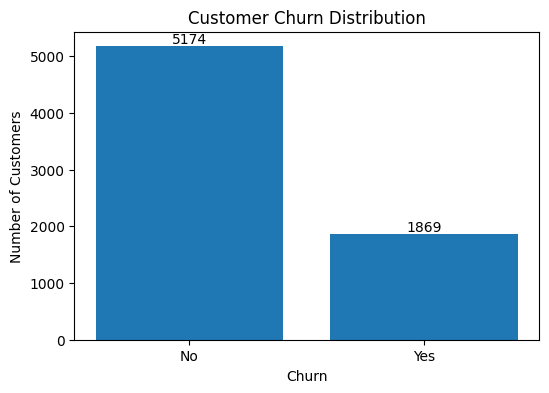

In [4]:
churn_counts = df_do_start.group_by("Churn").len().sort("Churn")

plt.figure(figsize=(6,4))
plt.bar(churn_counts["Churn"], churn_counts["len"])

for i, v in enumerate(churn_counts["len"]):
    plt.text(i, v + 50, str(v), ha="center")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

### Dataset Summary

- Customers: 7,043  
- Features: 21  
- Churn rate: ~26.5%  
- Industry: Telecom subscription services

From the dataset information on its website we know the following columns and their definitions:

| Column            | Definition  
|-------------------|---------------------------------------
| CustomerID:       | Unique customer identification number
| gender:           | Whether the customer is a male or a female
| SeniorCitizen:    | Whether the customer is a senior citizen or not (1, 0)
| Partner:          | Whether the customer has a partner or not (Yes, No)
| Dependents:       | Whether the customer has dependents or not (Yes, No)
| tenure:           | Number of months the customer has stayed with the company
| PhoneService:     | Whether the customer has a phone service or not (Yes, No)
| MultipleLines:    | Whether the customer has multiple lines or not (Yes, No, No phone service)
| InternetService:  | Customer’s internet service provider (DSL, Fiber optic, No)
| OnlineSecurity:   | Whether the customer has online security or not (Yes, No, No internet service)
| OnlineBackup:     | Whether the customer has online backup or not (Yes, No, No internet service)
| DeviceProtection: | Whether the customer has device protection or not (Yes, No, No internet service)
| TechSupport:      | Whether the customer has tech support or not (Yes, No, No internet service)
| StreamingTV:      | Whether the customer has streaming TV or not (Yes, No, No internet service)
| StreamingMovies:	| Whether the customer has streaming movies or not (Yes, No, No internet service)
| Contract:         | The contract term of the customer (Month-to-month, One year, Two year)
| PaperlessBilling: | Whether the customer has paperless billing or not (Yes, No)
| PaymentMethod:    | The customer’s payment method (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic))
| MonthlyCharges:   | The amount charged to the customer monthly
| TotalCharges:     | The total amount charged to the customer
| Churn:            | Whether the customer churned or not (Yes or No)

We can see that some of the characteristics are "stuck in time" e.g. tenure (which in any normal scenario would not exist. There would be customer_join/signup_date in customer table or contract table or something similar to depict when the customer became our "customer") or total charges (usually payments are not stored this way). 

We also have some missing values in total charges which we will need to investigate in exploratory analysis later.

Also we can immediately see that when we did very basic exploration for values of SeniorCitizen we treated it as a continuous variable even though it should be categorical one. So let's quickly fix our statistics:

In [5]:
# Basic statistics of the data:
continuous_columns = ["tenure", "MonthlyCharges", "TotalCharges"]  # These are the columns that are numeric; we treat them as continuous for simplicity.
categorical_columns = [col for col in df_do_start.columns if col not in continuous_columns and col != "customerID"]  # These are columns that are not numeric and not customerID; we treat them as categorical.

print("Basic statistics of the data:")
for col in df_do_start.columns:
    if col in continuous_columns:
        print(f"\nStatistics for column: {col}")
        print(df_do_start.select(pl.col(col)).describe())
    elif col in categorical_columns:
        print(f"\nValue counts for column: {col}")
        print(df_do_start.select(pl.col(col).value_counts()))

Basic statistics of the data:

Value counts for column: gender
shape: (2, 1)
┌─────────────────┐
│ gender          │
│ ---             │
│ struct[2]       │
╞═════════════════╡
│ {"Male",3555}   │
│ {"Female",3488} │
└─────────────────┘

Value counts for column: SeniorCitizen
shape: (2, 1)
┌───────────────┐
│ SeniorCitizen │
│ ---           │
│ struct[2]     │
╞═══════════════╡
│ {0,5901}      │
│ {1,1142}      │
└───────────────┘

Value counts for column: Partner
shape: (2, 1)
┌──────────────┐
│ Partner      │
│ ---          │
│ struct[2]    │
╞══════════════╡
│ {"No",3641}  │
│ {"Yes",3402} │
└──────────────┘

Value counts for column: Dependents
shape: (2, 1)
┌──────────────┐
│ Dependents   │
│ ---          │
│ struct[2]    │
╞══════════════╡
│ {"Yes",2110} │
│ {"No",4933}  │
└──────────────┘

Statistics for column: tenure
shape: (9, 2)
┌────────────┬───────────┐
│ statistic  ┆ tenure    │
│ ---        ┆ ---       │
│ str        ┆ f64       │
╞════════════╪═══════════╡
│ count      ┆

Now we have the correct basic statistics.

The dataset is relatively clean and well formatted. Even though it's already prepared very nicely for us and almost ready for modeling. It's good to discuss how data are stored in real scenarios.In real-world projects, analysts rarely work with a single fully prepared analytical table like this.  
Instead, data is typically distributed across multiple operational tables that must be joined and transformed before modeling.

## Key Insights

Several observations can be made from the initial inspection of the dataset:

- The dataset is well formatted and relatively clean. However, it contains derived fields such as tenure and TotalCharges. In real production systems, these values are typically calculated from subscription start dates and transaction tables, rather than stored directly.

- The variable SeniorCitizen is encoded as numeric (0/1) but actually represents a categorical attribute. It should therefore be treated as a categorical feature during analysis and modeling.

- There are 11 missing values in the TotalCharges column, which will need to be investigated during the data cleaning phase.

- The dataset contains 7043 customers, of which 1869 have churned, resulting in an overall churn rate of approximately:

```
churn_rate ≈ 1869 / 7043 ≈ 26.5%
```

This raises questions about how churn was defined in the dataset.

- In most subscription-based businesses, churn is measured over a specific time window, typically monthly:

```
monthly churn rate = customers who cancelled during the month / active customers at the start of the month
```

- If the observed churn rate of 26.5% represented a monthly churn rate, it would be unrealistically high for a telecom company.

- It is therefore more likely that the dataset represents a snapshot over a longer observation window, where the churn label indicates whether the customer has churned during the observed period.

- This interpretation would be consistent with typical annual churn rates in the telecom industry, which often fall between 20–35%.

- Despite these limitations, the dataset still provides sufficient information to explore relationships between customer characteristics, service usage, and churn behavior.

Because the dataset does not include timestamps of churn events, the exact churn calculation cannot be reconstructed. As a result, churn will be treated as a binary customer-level outcome rather than a time-based churn metric.

## Data Model Assumptions

The original dataset is provided as a single denormalized table.
However, in a real company data warehouse, this information would typically be split across several domain tables.

The following sections describe a simplified schema that approximates how such data might be organized in a production environment.

### Customer Table:

**Customer**

- CustomerID
- gender
- SeniorCitizen
- Partner
- Dependents
- signup_date*

*The signup date (or account activation date) may or may not exist in the customer table depending on the system design.

If available, the tenure of a customer can be calculated as:

`tenure = current_date - signup_date`

If the signup date is not stored directly in the customer table, it can often be derived from the first subscription start date in the subscription system.

Most companies maintain a customer dimension table that stores core demographic or account information. Additional operational data is typically stored in other domain tables linked through `CustomerID`

### Contracts / Subscription View

**contracts_view**

- CustomerID
- ContractType
- PaperlessBilling
- PaymentMethod
- MonthlyCharges
- InternetService
- PhoneService
- StreamingTV
- StreamingMovies
- OnlineSecurity
- OnlineBackup
- DeviceProtection
- status

The dataset contains a churn indicator, but real production systems usually store customer status instead.

`status = active | inactive`

In real production systems, customer activity is typically determined using fields such as:

- subscription_end_date
- subscription_status
- last_activity_date

Since the dataset does not contain such lifecycle events, the churn indicator is used to approximate a customer activity status.

### Billing and Product Structure (Simplified)

In real telecom or SaaS systems, monthly charges are usually not stored as a single column.

Instead, revenue is typically calculated from several operational tables such as:

**products**
- product_id
- product_name
- price

**subscriptions**
- subscription_id
- customer_id
- product_id
- start_date
- end_date

**transactions**
- transaction_id
- CustomerID
- amount
- transaction_date

This structure allows companies to track product usage, billing events, and revenue at a much more granular level.

### Customer Balance View

**customer_balance_view**

- CustomerID
- TotalCharges

The dataset only provides an aggregate total charge per customer.

Without transaction-level information, it is not possible to reconstruct a full payment history.

In a real data warehouse, this value would normally be calculated from a transaction or billing events table.

### Analytical Dataset

The final dataset used for modeling is constructed by joining the views above into a customer-level analytical table.

This table represents the feature dataset used for churn prediction.

## Next Steps:

- We will perform full data exploration analysis
- Derive additional insights from the findings
- Perform basic data engineering and cleaning
- Apply several different modeling techniques
- Explain the prediction for each model
- Select the best performing model

In [6]:
# save the data at the end of the notebook as input for the next notebook
df_do_start.write_csv("data/processed/01_do_telco_customer_churn_end.csv")